In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
import pyvista as pv
from mat4py import loadmat
import seaborn as sns
from scipy.stats import gaussian_kde
import matplotlib.colors as colors
from matplotlib.colors import PowerNorm

from matplotlib.textpath import TextPath
from matplotlib.patches import PathPatch
from matplotlib.transforms import Affine2D

In [2]:
all_recipes = []
for batch in range(100):
    file = f'params/e2e_samples_rng_42_batch_{batch}.npy'
    with open(file, 'rb') as f:
        arr = pickle.load(f)
    all_recipes.append(arr)
all_recipes = np.vstack(all_recipes)

In [3]:
with open('data/burgers_step8.pkl', 'rb') as f:
    gt_recipes, ingr_names, calorie_database = pickle.load(f)
n_ingr = len(ingr_names)
gt_mask = np.array(gt_recipes>0, dtype='int32')

## Palatability vs Env score vs Nutrition

In [4]:
# Load all environmental scores
with open(f'params/all_env_impacts_rng_42.pkl', 'rb') as f:
    env, includes_buns = pickle.load(f)

# Load all nutrition scores
hei = np.loadtxt(f'params/hei_scores_seed_42_1m.txt')[1] # we don't need the indices

# Load all recipe repetitions
out = []
for batch in range(100):
    temp = np.loadtxt(f'params/repeat_counts_first_1m_rng_42_batch_{batch}.txt')
    out.append(temp)
repeats = np.vstack(out)[:,1] # we don't need the indices


# # for now limit to the first 100k samples
# env = env[:10_000]
# hei = hei[:10_000]
# repeats = repeats[:10_000]
# all_recipes = all_recipes[:10_000]

In [5]:
ymin = 0
ymax = 1.7
xmin = 12
xmax = 90

idx = np.logical_and(hei > xmin, 
                     np.logical_and(hei < xmax, 
                                    np.logical_and(env > ymin, env < ymax)))
x = hei[idx]
y = env[idx]
c = repeats[idx]


In [6]:
def draw_containment_curve(target_name, ax, threshold=0.025, idx_ingr=None, positions=[(1.0, -10.0)], linestyles=[(0, (12, 8))]):
    if idx_ingr is None:
        idx_ingr = all_recipes[:,np.where(ingr_names==target_name)[0][0]] > 0
        idx_ingr = np.logical_and(idx_ingr, idx)
    x_ingr = hei[idx_ingr]
    y_ingr = env[idx_ingr]
    c_ingr = repeats[idx_ingr]
    pts_ingr = np.vstack([x_ingr, y_ingr]).T
    # KDE
    kde = gaussian_kde(pts_ingr.T, bw_method=0.4)  # bandwidth controls smoothness
    x_plot, y_plot = np.meshgrid(np.linspace(12,90,300), np.linspace(0,1.7,300))
    grid_coords = np.vstack([x_plot.ravel(), y_plot.ravel()])
    z_plot = kde(grid_coords).reshape(x_plot.shape)
    # Draw contour at chosen level
    # plt.scatter(pts_beef[:,0], pts_beef[:,1], s=10, c='black')
    contour = ax.contour(x_plot, y_plot, z_plot, levels=[threshold], colors='gray', linewidths=1, linestyles=linestyles)  # pick density threshold

    custom_labels = {
        threshold: target_name,
    }
    plt.clabel(contour, inline=True, fmt=custom_labels, fontsize=12, manual=positions)

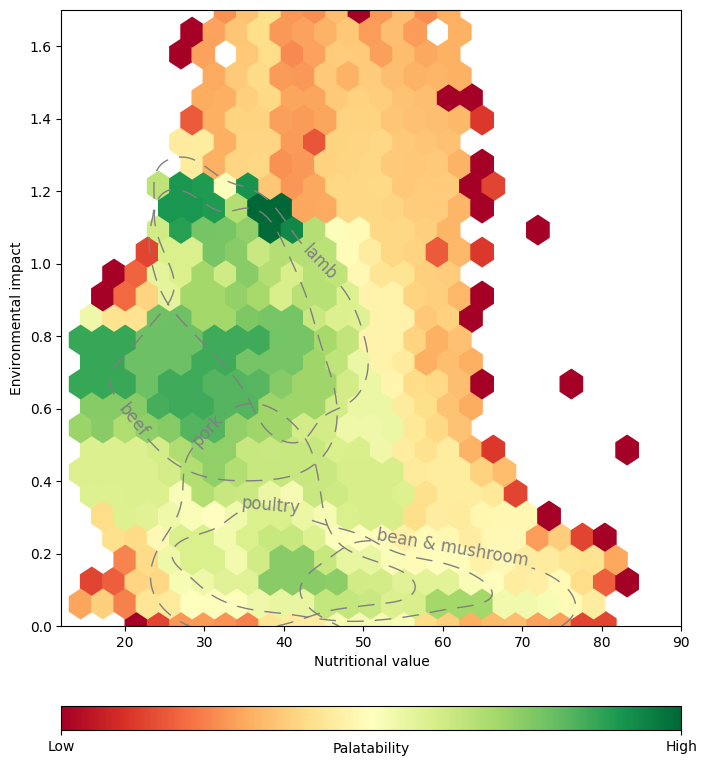

In [7]:
fig, ax = plt.subplots(figsize=(8,8))
norm = PowerNorm(gamma=0.25)
hb = ax.hexbin(x, y, C=c, cmap='RdYlGn', norm=norm, gridsize=25, reduce_C_function=np.max)
ax.set(xlabel='Nutritional value', ylabel='Environmental impact'); 


# Plot closed curves for different protein sources
draw_containment_curve('beef', ax, positions=[(20, 0.55)])
draw_containment_curve('lamb', ax, positions=[(42, 0.95)])
# draw_containment_curve('bean', ax, positions=[(68, 0.2)])
draw_containment_curve('pork', ax, positions=[(30, 0.55)])


# Poultry
idx_ingr_1 = all_recipes[:,np.where(ingr_names=='chicken')[0][0]] > 0
idx_ingr_2 = all_recipes[:,np.where(ingr_names=='turkey')[0][0]] > 0
idx_ingr = np.logical_and(idx, np.logical_or(idx_ingr_1, idx_ingr_2))
draw_containment_curve('poultry', ax, idx_ingr=idx_ingr, positions=[(38,0.3)])

# Mushrooms (only)
idx_ingr = all_recipes[:,np.where(ingr_names=='mushroom')[0][0]] > 0
mask2 = all_recipes[:,np.where(ingr_names=='beef')[0][0]] == 0
mask3 = all_recipes[:,np.where(ingr_names=='lamb')[0][0]] == 0
mask4 = all_recipes[:,np.where(ingr_names=='pork')[0][0]] == 0
mask5 = all_recipes[:,np.where(ingr_names=='bean')[0][0]] == 0
mask6 = all_recipes[:,np.where(ingr_names=='turkey')[0][0]] == 0
mask7 = all_recipes[:,np.where(ingr_names=='chicken')[0][0]] == 0
idx_ingr = np.logical_and(idx_ingr, 
                          np.logical_and(idx, np.logical_and(mask2, 
                                                             np.logical_and(mask3, np.logical_and(mask4, 
                                                                                                  np.logical_and(mask5, np.logical_and(mask6, mask7)))))))
# draw_containment_curve('mushroom', ax, idx_ingr=idx_ingr, positions=[(40, 0.3)])

# Bean & mushroom
mask8 = all_recipes[:,np.where(ingr_names=='bean')[0][0]] > 0
idx_ingr = np.logical_or(idx_ingr, mask8)
draw_containment_curve('bean & mushroom', ax, idx_ingr=idx_ingr, positions=[(61, 0.2)])


cbar_ax = fig.add_axes([0.125, -0.02, 0.775, 0.03])
cb = fig.colorbar(hb, cax=cbar_ax, orientation='horizontal')
cb.set_ticks([cb.vmin, cb.vmax])
cb.set_ticklabels(["Low", "High"])
cb.set_label("Palatability")
cb.ax.xaxis.set_label_coords(0.5, -0.5)

# fig.savefig('figs/palatability_contour.pdf', bbox_inches='tight')

Observations:
1. We have actually captured the human palate inside a figure (at least a subspace thereof). This chili pepper shaped blob is the human palate. The white parts are outside of the human diet, those are not real foods. So, for example, there are no burgers in the human diet that has an environmental impact of 1.2 and nutritional value of 70.
2. Notice that as expected, and unfortunately, all the delicious foods are in the upper left corner (i.e. high environmental impact and low nutritional value). This is exactly what makes our work challenging. We want to approach the lower right corner and be green.
3. We are still very lucky though, because it looks like we CAN approach the lower right corner (unlike the upper right, for example). 
4. Notice how all the edges of the blob are red. This is because those burgers are at the boundary of the human palate. Those are barely real foods at all. Beyond those is inedible.

In [75]:
from matplotlib.colors import to_rgba
from matplotlib.patches import Polygon

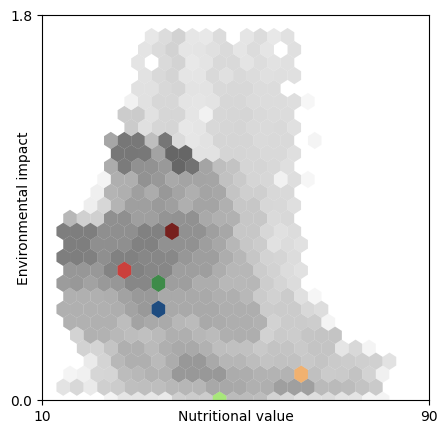

In [81]:
fig, ax = plt.subplots(figsize=(5,5))
norm = PowerNorm(gamma=0.25)
hb = ax.hexbin(x, y, C=c, cmap='Greys', norm=norm, gridsize=25, reduce_C_function=np.max, alpha=0.6, edgecolor=None)
ax.set(xlabel='Nutritional value', ylabel='Environmental impact', xticks=[10,90], yticks=[0,1.8], xlim=(10,90), ylim=(0,1.8)); 

ax.set_xlabel('Nutritional value', labelpad=-10)
ax.set_ylabel('Environmental impact', labelpad=-15)

coords = [[37.3, 0.74],
          [27.3, 0.65],
          [47.11, 0.032],
          [34.52, 0.51],
          [63.14, 0.079],
          [33.71, 0.46]]

colors = [np.array([119, 32, 29])/256,
          np.array([204, 64, 60])/256,
          np.array([169, 232, 122])/256,
          np.array([62, 140, 73])/256,
          np.array([242, 178, 111])/256,
          np.array([30, 76, 128])/256]

# for coord, color in zip(coords, colors):
#     ax.scatter(coord[0], coord[1], color=color, s=10, edgecolor='black')

centers = hb.get_offsets()
hex_verts = hb.get_paths()[0].vertices

for (xp, yp), cp in zip(coords, colors):
    d2 = (centers[:, 0] - xp)**2 + (centers[:, 1] - yp)**2
    idx = np.argmin(d2)

    verts = hex_verts + centers[idx]
    poly = Polygon(
        verts,
        facecolor=cp,
        edgecolor='none',
        zorder=hb.get_zorder() + 1
    )
    ax.add_patch(poly)


fig.savefig('figs/palatability_contour2.pdf', bbox_inches='tight')

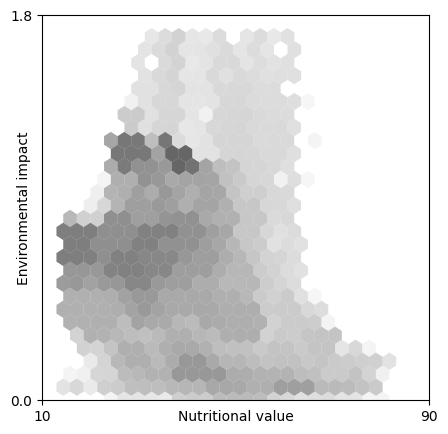

In [83]:
fig, ax = plt.subplots(figsize=(5,5))
norm = PowerNorm(gamma=0.25)
hb = ax.hexbin(x, y, C=c, cmap='Greys', norm=norm, gridsize=25, reduce_C_function=np.max, alpha=0.6, edgecolor=None)
ax.set(xlabel='Nutritional value', ylabel='Environmental impact', xticks=[10,90], yticks=[0,1.8], xlim=(10,90), ylim=(0,1.8)); 

ax.set_xlabel('Nutritional value', labelpad=-10)
ax.set_ylabel('Environmental impact', labelpad=-15)

# for coord, color in zip(coords, colors):
#     ax.scatter(coord[0], coord[1], color=color, s=10, edgecolor='black')

fig.savefig('figs/palatability_contour3.pdf', bbox_inches='tight')

# Spider web plots 

In [45]:
# get bounds for environmental impact
with open('data/environmental/trn_recipes_env_impacts.pkl', 'rb') as f:
    trn_data_env_impacts, trn_data_lu, trn_data_ghg, trn_data_wu, trn_data_ep = pickle.load(f)

env_max, env_min = np.max(trn_data_env_impacts), np.min(trn_data_env_impacts)

def env_2_eco(env_impact):
    return (env_max - env_impact)/(env_max - env_min)

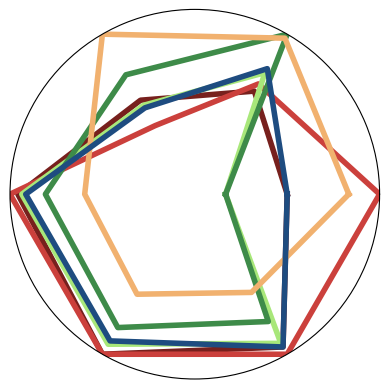

In [134]:
# Example data
labels = ['Novelty', 'Eco-friendliness *', 'Nutrition', 'Overall Liking', 'Flavor', 'Texture']
fig, ax = plt.subplots(subplot_kw=dict(polar=True))

values_list = [[3/6, env_2_eco(0.74), 37/100, (5.5-1)/6, (5.8-1)/6, (5.2-1)/6], # delicious 1
               [6/6, env_2_eco(0.65), 27/100, (5.7-1)/6, (5.8-1)/6, (5.4-1)/6], # delicious 2
               [1/6, env_2_eco(0.51), 35/100, (5.4-1)/6, (5.5-1)/6, (5.1-1)/6], # sustainable 1
               [1/6, env_2_eco(0.03), 47/100, (4.8-1)/6, (5.0-1)/6, (4.5-1)/6], # sustainable 2
               [5/6, env_2_eco(0.08), 63/100, (3.8-1)/6, (4.0-1)/6, (3.7-1)/6], # nutritious
               [3/6, env_2_eco(0.46), 34/100, (5.3-1)/6, (5.4-1)/6, (5.2-1)/6]] # big mac
values_arr = np.array(values_list)
vmax = values_arr.max(axis=0)
vmin = values_arr.min(axis=0)*0


colors = [np.array((119, 32, 29))/256,
          np.array((204, 64, 60))/256,
          np.array((169, 232, 122))/256,
          np.array((62, 140, 73))/256,
          np.array((242, 178, 111))/256,
          np.array((30, 76, 128))/256]

for i in range(len(values_arr)):
    values = list(values_arr[i])
    values = (values-vmin)/(vmax-vmin)
    values = list(values)
    # Repeat the first value to close the circle
    values += values[:1]
    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
    angles += angles[:1]

    # Create radar chart
    ax.plot(angles, values, linewidth=4, color=colors[i])
    # ax.fill(angles, values, alpha=0.25)

# Add category labels
ax.set_thetagrids(np.degrees(angles[:-1]), labels)
ax.set(yticklabels=[], ylim=[0,1])

fig.savefig('figs/spider_1.pdf')


ax.set_thetagrids(np.degrees(angles[:-1]), [None]*len(labels))
fig.savefig('figs/spider_2.pdf')


ax.set(yticks=[])
fig.savefig('figs/spider_3.pdf')

ax.set(xticks=[])
fig.savefig('figs/spider_4.pdf')

# Print out a recipe for supplement 1

In [3]:
burgers = pd.read_csv('data/burgers.csv')

In [52]:
path1 = kagglehub.dataset_download("irkaal/foodcom-recipes-and-reviews") + '/recipes.csv'
df1 = pd.read_csv(path1)

path2 = kagglehub.dataset_download("realalexanderwei/food-com-recipes-with-ingredients-and-tags")  + '/recipes_ingredients.csv'
df2 = pd.read_csv(path2)

# Ensure matching data types
df1['RecipeId'] = pd.to_numeric(df1['RecipeId'], errors='coerce')
df2['id'] = pd.to_numeric(df2['id'], errors='coerce')

# Drop duplicates: keep only the first ingredient entry per recipe
df2_unique = df2[['id', 'ingredients_raw', 'ingredients']].drop_duplicates(subset='id')

# Merge
data = df1.merge(df2_unique, left_on='RecipeId', right_on='id', how='left')
data.drop(columns='id', inplace=True)

In [54]:
i = 4
name = burgers.iloc[i]['Name']
instr = eval(burgers.iloc[i]['RecipeInstructions'][1:])
target = data[data["Name"] == "Ken's Hamburgers"].iloc[0]

In [63]:
print('Recipe ID: ', target.RecipeId)
print('Name: ', target.Name)
print('Author ID: ', target.AuthorId)
print('Author Name: ', target.AuthorName)
print('Cook Time: ', target.CookTime)
print('Prep Time: ', target.PrepTime)
print('Total Time: ', target.TotalTime)
print('Date Published: ', target.DatePublished)
print('Description: ', target.Description)
print('Images: ', target.Images)
print('Recipe Category: ', target.RecipeCategory)
print('Keywords: ', target.Keywords)
print('Ingredients: ', target.ingredients_raw)
print('Recipe Instructions: ', target.RecipeInstructions)
print('Aggregated Rating: ', target.AggregatedRating)
print('Review Count: ', target.ReviewCount)
print('Calories: ', target.Calories)
print('Fat Content: ', target.FatContent)

Recipe ID:  2734
Name:  Ken's Hamburgers
Author ID:  1575
Author Name:  lindaWWJD
Cook Time:  PT10M
Prep Time:  PT10M
Total Time:  PT20M
Date Published:  1999-08-25T05:21:00Z
Description:  Make and share this Ken's Hamburgers recipe from Food.com.
Images:  c("https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/27/34/picgsfaLB.jpg", "https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/27/34/picaPkIS9.jpg")
Recipe Category:  Meat
Keywords:  c("Very Low Carbs", "High Protein", "Kid Friendly", "High In...", "Broil/Grill", "< 30 Mins", "Oven", "Easy")
Ingredients:  ["1/3  lb    lean ground beef (per burger)","1 1/2  teaspoons    barbecue sauce","1/4  teaspoon    dehydrated onion, minced "]
Recipe Instructions:  c("Allow 1/3 lb. lean ground beef per burger.", "To each burger, add 1 1/2 teaspoons barbeque sauce and 1/4 teaspoon dehydrated minced onion.", "Cook on broiler, turning about every 4 minutes.", "Also

# Print ingredient FDC codes

In [12]:
from utils import usda_codes
try:
    usda_codes.pop('patty')
except:
    pass
try:
    usda_codes.pop('water')
except:
    pass
usda_codes = list(usda_codes.items())
# make it divisible by 3
usda_codes.append((' ', ' '))

In [13]:
ncols = 3
nrows = (len(usda_codes) + ncols - 1) // ncols

cols = [usda_codes[i*nrows:(i+1)*nrows] for i in range(ncols)]

for row in zip(*cols):
    out = []
    for entry in row:
        out.append(entry[0])
        out.append(str(entry[1]))
    print(' & '.join(out) + r' \\ ')

allspice & 171315 & curry powder & 170924 & pasta & 168927 \\ 
almond & 2707486 & dill & 172233 & peanut & 2515376 \\ 
apple & 2709215 & dough & 172791 & pepper & 170931 \\ 
arugula & 2709791 & dressing & 173592 & pesto & 171582 \\ 
avocado & 2709223 & egg & 171287 & pickle & 169379 \\ 
bacon & 168277 & feta & 173420 & pimento & 168559 \\ 
barbecue sauce & 174523 & fish & 2706284 & pineapple & 169124 \\ 
basil & 172232 & flour & 169761 & pork & 2705863 \\ 
bean & 173744 & garlic & 169230 & portobello & 169255 \\ 
beef & 2514743 & ginger & 169231 & potato & 170027 \\ 
beer & 168749 & goat cheese & 2705716 & provolone & 170850 \\ 
beet & 2685576 & gouda & 171241 & quinoa & 168874 \\ 
blue cheese & 172175 & green onion & 170005 & ranch sauce & 173592 \\ 
bouillon & 171562 & greens & 2709792 & relish & 168561 \\ 
breadcrumb & 1930877 & guacamole & 2709307 & rice & 168879 \\ 
broth & 172883 & hoisin sauce & 172886 & rosemary & 173473 \\ 
brown sugar & 2710260 & honey & 169640 & sage & 17093

In [11]:
cols[0]

[('allspice', 171315),
 ('almond', 2707486),
 ('apple', 2709215),
 ('arugula', 2709791),
 ('avocado', 2709223),
 ('bacon', 168277),
 ('barbecue sauce', 174523),
 ('basil', 172232),
 ('bean', 173744),
 ('beef', 2514743),
 ('beer', 168749),
 ('beet', 2685576),
 ('blue cheese', 172175),
 ('bouillon', 171562),
 ('breadcrumb', 1930877),
 ('broth', 172883),
 ('brown sugar', 2710260),
 ('buffalo', 175299),
 ('bulgur', 2710820),
 ('bun', 2707784),
 ('butter', 173430),
 ('cabbage', 169975),
 ('cajun seasoning', 1887349),
 ('carrot', 2709660),
 ('cayenne pepper', 170932),
 ('celery', 2709778),
 ('cheddar cheese', 2705709),
 ('other cheese', 2705764),
 ('chicken', 2706091),
 ('chicken seasoning', 2060346),
 ('chickpea', 173756),
 ('chili', 170497),
 ('chili flake', 579086),
 ('chip', 2709434),
 ('chipotle chili', 2009291),
 ('chive', 2709781),
 ('cilantro', 169997),
 ('cinnamon', 171320),
 ('coriander seed', 170922),
 ('corn', 2709783),
 ('cornflour', 2710835),
 ('cottage cheese', 172182),
 ('cra

In [10]:
49*3

147